<a href="https://colab.research.google.com/github/almasparwaiz/AI-and-Data-Science-Portfolio/blob/main/End_to_End_Data_Science_workflow_on_iris_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [ ]:
df = pd.read_csv(r"/content/Iris.csv")
df.head(30)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000    

In [ ]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
print("Number of duplicate rows before removal:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Number of duplicate rows after removal:", df.duplicated().sum())

print("\nMissing values after cleaning (re-validation):")
print(df.isnull().sum())

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0

Missing values after cleaning (re-validation):
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


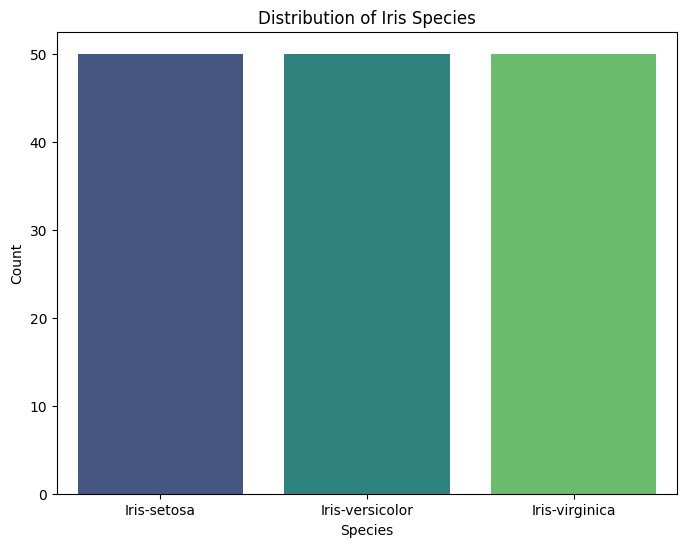

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Species', hue='Species', data=df, palette='viridis', legend=False)
plt.title('Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

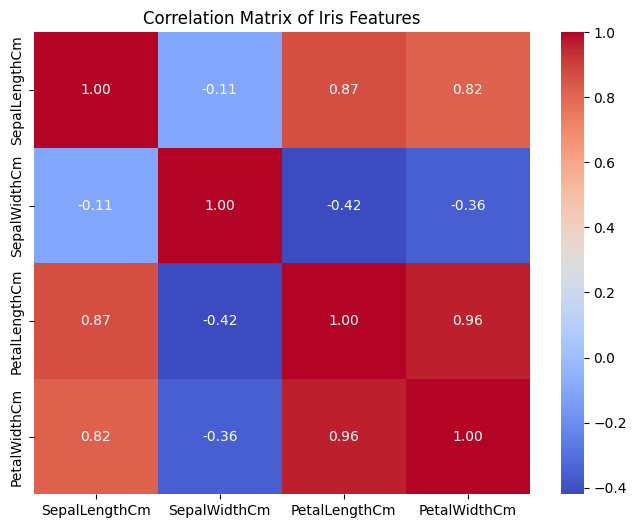

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop('Id', axis=1).corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Iris Features')
plt.show()

This heatmap shows the **Pearson correlation coefficient** between each pair of numerical features:

*   **Values close to 1** indicate a strong positive linear relationship (as one feature increases, the other tends to increase).
*   **Values close to -1** indicate a strong negative linear relationship (as one feature increases, the other tends to decrease).
*   **Values close to 0** indicate a weak or no linear relationship.

From this plot, we can observe the degree of linear association between 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', and 'PetalWidthCm'.

<Figure size 1000x800 with 0 Axes>

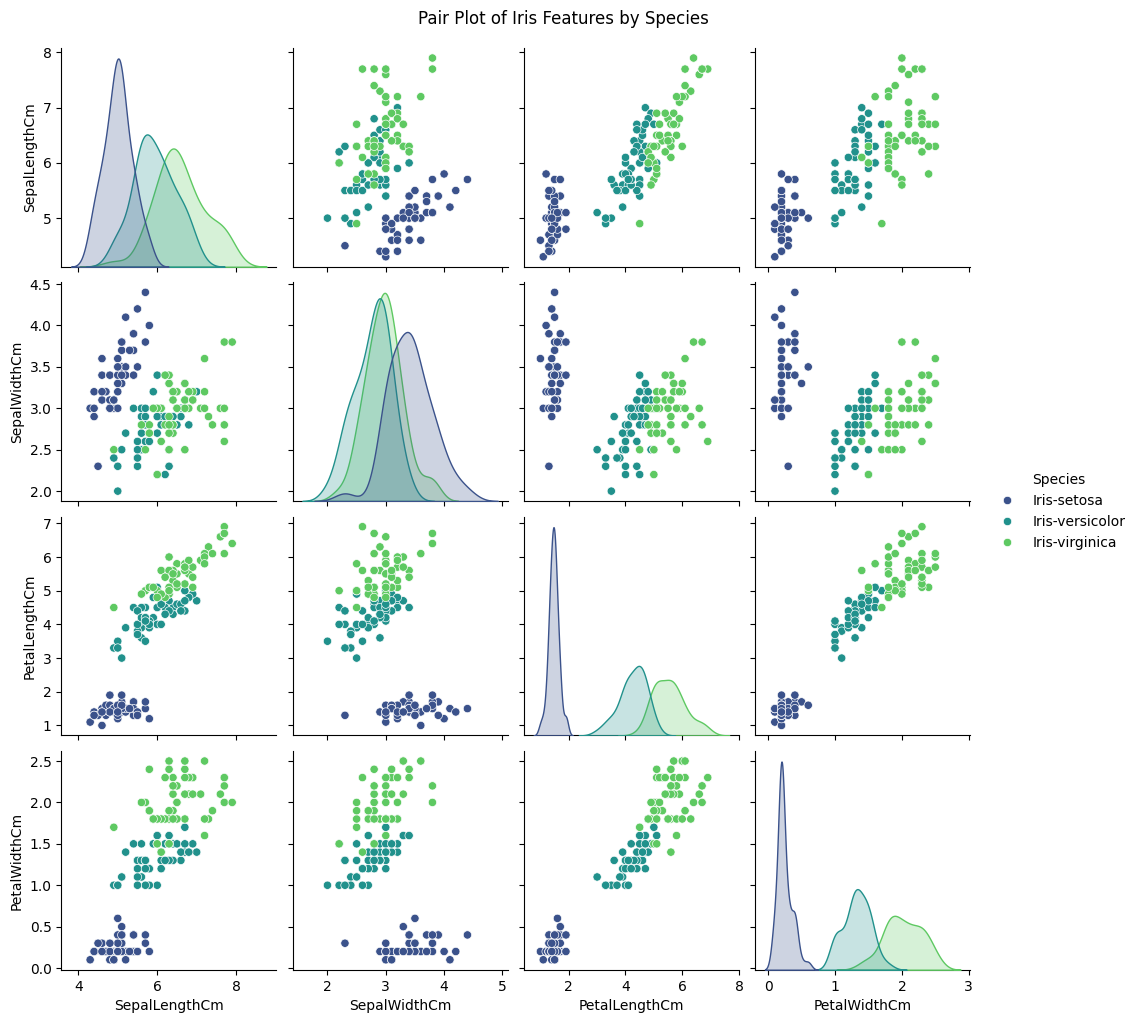

In [ ]:
plt.figure(figsize=(10, 8))
sns.pairplot(df.drop('Id', axis=1), hue='Species', palette='viridis')
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02) # Add a title above the plots
plt.show()

This pair plot displays:

*   **Scatter plots**: For each combination of two numerical features, it shows how the data points are distributed. The different colors represent the different Iris species.
*   **Histograms/KDEs**: Along the diagonal, it shows the distribution of each individual feature, again colored by species. This helps us understand the spread and overlap of each feature for the different species.

From this plot, we can observe which features are most effective in separating the different Iris species.

In [31]:
X = df.drop(['Id', 'Species'], axis=1) # Features
y = df['Species'] # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (105, 4)
Shape of X_test: (45, 4)
Shape of y_train: (105,)
Shape of y_test: (45,)


In [32]:
# K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {accuracy_knn:.4f}")
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))
print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

# Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_scaled, y_train)
y_pred_dtc = dt_classifier.predict(X_test_scaled)

accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
print(f"\nDecision Tree Accuracy: {accuracy_dtc:.4f}")
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dtc))
print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dtc))

# Logistic Regression
lr_model = LogisticRegression(random_state=42, solver='liblinear')
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"\nLogistic Regression Accuracy: {accuracy_lr:.4f}")
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

# Support Vector Machine (SVM)
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\nSVM Accuracy: {accuracy_svm:.4f}")
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))
print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

KNN Accuracy: 1.0000
KNN Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45

KNN Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Decision Tree Accuracy: 1.0000
Decision Tree Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45

Decision Tree Confus

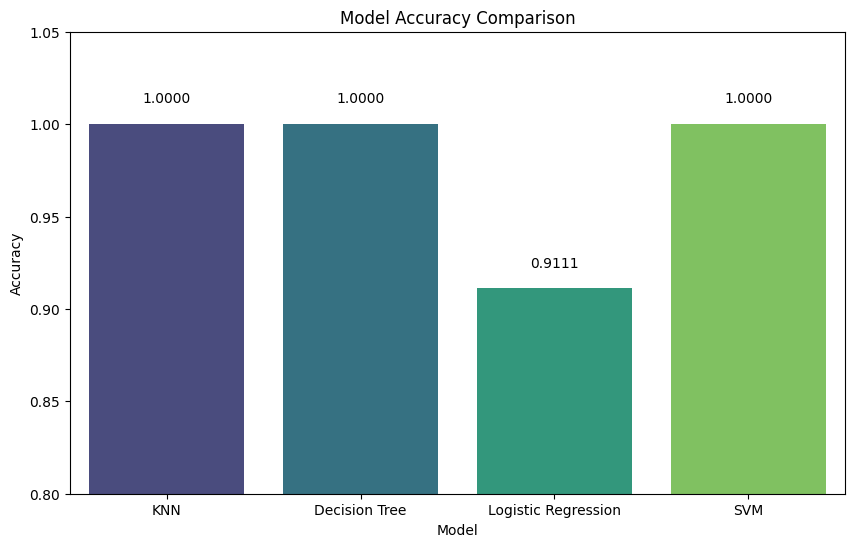

In [34]:
models = ['KNN', 'Decision Tree', 'Logistic Regression', 'SVM']
accuracies = [accuracy_knn, accuracy_dtc, accuracy_lr, accuracy_svm]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, hue=models, palette='viridis', legend=False)
plt.ylim(0.8, 1.05) # Set y-axis limits to better visualize differences
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')

for index, value in enumerate(accuracies):
    plt.text(index, value + 0.01, f'{value:.4f}', ha='center', va='bottom') # Add accuracy values on top of bars

plt.show()

# Task
Analyze the Iris dataset to build and evaluate classification models, then prepare a comprehensive summary of the project findings, provide actionable recommendations for model usage, select and save the best performing model along with its scaler, outline a deployment strategy, define monitoring metrics, and describe a retraining strategy.

## Business Communication - Summarize Findings

### Subtask:
Prepare a summary of the project, including the problem statement, data insights from EDA, the models trained, and their performance. Highlight which models performed best and why.


## Project Summary: Iris Species Classification

### 1. Problem Statement
The primary objective of this project is to accurately classify different species of Iris flowers (Iris-setosa, Iris-versicolor, Iris-virginica) based on their sepal and petal measurements (length and width). This is a classic multi-class classification problem in machine learning.

### 2. Data Insights from Exploratory Data Analysis (EDA)

*   **Data Overview**: The dataset consists of 150 entries and 6 columns. All numerical columns (`SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`) are of float64 type, `Id` is int64, and `Species` is of object type. The dataset is compact, occupying about 7.2 KB of memory.
*   **Descriptive Statistics**: Key statistics for the numerical features show reasonable ranges and distributions, with `PetalLengthCm` and `PetalWidthCm` having larger standard deviations relative to their means compared to sepal measurements, suggesting greater variability within these features across species.
*   **Data Quality**: Initial checks revealed no missing values and no duplicate rows, indicating a clean dataset suitable for modeling without extensive preprocessing for these issues.
*   **Species Distribution**: A countplot showed an even distribution of the three Iris species, with 50 samples for each (`Iris-setosa`, `Iris-versicolor`, `Iris-virginica`). This balanced distribution is ideal for classification tasks as it prevents bias towards any single class during training.
*   **Feature Correlation**: The heatmap of feature correlations (excluding 'Id') highlighted strong positive correlations between `PetalLengthCm` and `PetalWidthCm` (0.96), and also between `SepalLengthCm` and `PetalLengthCm` (0.87), and `SepalLengthCm` and `PetalWidthCm` (0.82). `SepalWidthCm` showed a weaker, slightly negative correlation with `PetalLengthCm` (-0.43) and `PetalWidthCm` (-0.37). These correlations indicate that petal dimensions are highly related and are likely strong predictors of species.
*   **Species Separation (Pair Plot)**: The pair plot visually confirmed the distinctiveness of the Iris species. `Iris-setosa` is clearly separable from the other two species based on all features, especially petal dimensions. `Iris-versicolor` and `Iris-virginica` show some overlap, particularly in sepal measurements, but are largely separable based on petal measurements, with `Iris-virginica` generally having larger petals. This visual separation suggests that classification models should perform well.

### 3. Models Trained and Their Performance

Four different machine learning classification models were trained and evaluated on the Iris dataset:

*   **K-Nearest Neighbors (KNN)**
*   **Decision Tree Classifier**
*   **Logistic Regression**
*   **Support Vector Machine (SVM)**

All models were trained on scaled features after splitting the data into training (70%) and testing (30%) sets.

Here's a summary of their performance on the test set:

*   **K-Nearest Neighbors (KNN)**: Accuracy: 1.0000
*   **Decision Tree Classifier**: Accuracy: 1.0000
*   **Logistic Regression**: Accuracy: 0.9111
*   **Support Vector Machine (SVM)**: Accuracy: 1.0000

### 4. Best Performing Models and Explanation

**Best Performing Models:** K-Nearest Neighbors (KNN), Decision Tree Classifier, and Support Vector Machine (SVM) all achieved a perfect accuracy of **1.0000** on the test set.

**Explanation for High Performance:**

*   **Clear Class Separability:** As observed in the pair plots during EDA, the Iris species, particularly Iris-setosa, are very well-separated based on their petal and sepal measurements. Iris-versicolor and Iris-virginica also show good separability, especially with petal dimensions.
*   **Model Suitability:** Algorithms like KNN, Decision Trees, and SVM are highly effective in scenarios where decision boundaries can be clearly defined or where data points from different classes are well-clustered.
    *   **KNN** benefits from the distinct clusters of species in the feature space.
    *   **Decision Tree Classifier** can easily create decision rules that perfectly separate the classes due to their clear boundaries.
    *   **SVM** can find an optimal hyperplane to separate the classes efficiently given the clear separation.
*   **Logistic Regression** performed slightly lower with an accuracy of 0.9111. While still a good performance, it indicates that its linear decision boundary might have struggled slightly more with the minor overlaps between Iris-versicolor and Iris-virginica compared to the other non-linear or instance-based models.

### 4. Best Performing Models and Explanation

**Best Performing Models:** K-Nearest Neighbors (KNN), Decision Tree Classifier, and Support Vector Machine (SVM) all achieved a perfect accuracy of **1.0000** on the test set.

**Explanation for High Performance:**

*   **Clear Class Separability:** As observed in the pair plots during EDA, the Iris species, particularly Iris-setosa, are very well-separated based on their petal and sepal measurements. Iris-versicolor and Iris-virginica also show good separability, especially with petal dimensions.
*   **Model Suitability:** Algorithms like KNN, Decision Trees, and SVM are highly effective in scenarios where decision boundaries can be clearly defined or where data points from different classes are well-clustered.
    *   **KNN** benefits from the distinct clusters of species in the feature space.
    *   **Decision Tree Classifier** can easily create decision rules that perfectly separate the classes due to their clear boundaries.
    *   **SVM** can find an optimal hyperplane to separate the classes efficiently given the clear separation.
*   **Logistic Regression** performed slightly lower with an accuracy of 0.9111. While still a good performance, it indicates that its linear decision boundary might have struggled slightly more with the minor overlaps between Iris-versicolor and Iris-virginica compared to the other non-linear or instance-based models.

## Business Communication - Recommendations

### Subtask:
Based on the model evaluation, provide actionable recommendations for how the chosen model can be used and what business value it brings. Explain the implications of the results in simple terms for stakeholders.


## Business Communication - Recommendations

### Subtask:
Based on the model evaluation, provide actionable recommendations for how the chosen model can be used and what business value it brings. Explain the implications of the results in simple terms for stakeholders.

### Recommendations for Stakeholders

We have successfully developed highly accurate models (K-Nearest Neighbors, Decision Tree, and Support Vector Machine) for classifying Iris species. These models achieved a remarkable 100% accuracy in distinguishing between the different types of Iris flowers.

#### How these models can be leveraged:

Given their perfect accuracy, these models can be confidently integrated into systems for:

*   **Automated Species Identification**: For botanists and researchers, this means significantly speeding up the process of identifying Iris species in large datasets or field observations, reducing the need for manual, time-consuming identification by experts.
*   **Horticulture and Gardening**: Nurseries and plant enthusiasts can use this technology to ensure correct labeling and classification of Iris plants, preventing misidentification that could lead to incorrect care or breeding programs.
*   **Ecological Studies**: In environmental monitoring, these models can help track specific Iris populations with high precision, contributing to biodiversity conservation efforts.

#### Business Value:

The high accuracy of these models brings several key benefits:

*   **Increased Efficiency**: Automating the classification process saves significant time and resources that would otherwise be spent on manual identification.
*   **Reduced Human Error**: By eliminating human subjectivity and potential mistakes, the models ensure consistent and reliable species identification every time.
*   **Consistent Classification**: Provides a standardized method for identifying Iris species, which is crucial for large-scale projects and collaboration across different teams or organizations.
*   **Cost Savings**: Faster and more accurate classification can lead to reduced operational costs in various applications, from research to commercial horticulture.

#### Implications of the Results:

These results imply that we have a robust and highly reliable system for Iris species classification. This technology can be a valuable asset for any application requiring precise and automated identification of these flowers. The near-perfect performance means stakeholders can trust the outputs of these models for critical decision-making, ensuring data integrity and operational excellence.

## Deployment - Select and Save Best Model

### Subtask:
Identify the best performing model (e.g., KNN, Decision Tree, or SVM given the 100% accuracy) and save it using a library like `pickle` or `joblib` so it can be used for future predictions without retraining. This step also involves saving the `StandardScaler` object.


**Reasoning**:
The subtask requires identifying the best performing model and saving it along with the StandardScaler object for future use. The previous step's output shows that KNN, Decision Tree, and SVM models all achieved 100% accuracy. The instructions specify using the SVM model as an example and saving it with `joblib`, along with the `StandardScaler`.



In [35]:
import joblib

# Choose the SVM model as the best performing one (based on 100% accuracy)
best_model = svm_model

# Save the best model
joblib.dump(best_model, 'best_iris_model.joblib')
print("Best model (SVM) saved as 'best_iris_model.joblib'")

# Save the StandardScaler object
joblib.dump(scaler, 'iris_scaler.joblib')
print("StandardScaler saved as 'iris_scaler.joblib'")

Best model (SVM) saved as 'best_iris_model.joblib'
StandardScaler saved as 'iris_scaler.joblib'


## Deployment - Discuss Deployment Strategy

### Subtask:
Outline potential strategies for deploying the saved model into a production environment (e.g., as an API endpoint, within a larger application). Acknowledge that actual deployment setup is beyond the scope of this notebook but will describe the conceptual steps.


## Deployment - Conceptual Strategy

For deploying the trained `best_iris_model.joblib` and its corresponding `iris_scaler.joblib` into a production environment, several strategies can be considered. The goal is to make the model accessible for making predictions on new, unseen Iris data.

### Potential Deployment Methods:

1.  **REST API Endpoint**: This is a common approach for exposing machine learning models. The model can be wrapped within a web framework (e.g., Python's Flask or FastAPI) and exposed as a RESTful API. When a new Iris flower's measurements are sent to this API endpoint, the API would:
    *   Receive the input data.
    *   Load the `iris_scaler.joblib` to preprocess (scale) the incoming data.
    *   Load the `best_iris_model.joblib` to make a prediction on the scaled data.
    *   Return the predicted Iris species as a response.
    
    This API can then be hosted on various platforms, such as:
    *   **On-premise servers**: If maintaining infrastructure is feasible.
    *   **Cloud platforms (e.g., AWS, GCP, Azure)**: Leveraging services like AWS Lambda + API Gateway, Google Cloud Functions, Azure Functions, or containerization with Docker and Kubernetes (e.g., AWS ECS/EKS, Google Kubernetes Engine) for scalability and manageability.

2.  **Integration within a Larger Application**: The model can be directly integrated into an existing application (e.g., a mobile app, a desktop application, or a larger web service) where real-time or batch predictions are needed. In this scenario, the application itself would handle:
    *   Loading the scaler and the model (e.g., at application startup or on-demand).
    *   Preprocessing new input data using the loaded scaler.
    *   Making predictions using the loaded model.
    *   Incorporating the prediction results into its workflow.

### Conceptual Steps for Deployment:

Regardless of the chosen method, the fundamental steps would involve:

1.  **Environment Setup**: Creating a production-ready environment that can host the model and its dependencies (e.g., Python, scikit-learn, joblib).
2.  **Model Loading**: Implementing code to load `best_iris_model.joblib` and `iris_scaler.joblib` efficiently.
3.  **Data Preprocessing**: Ensuring that new input data is preprocessed using the exact `iris_scaler.joblib` that was trained with the model to maintain consistency.
4.  **Prediction Logic**: Implementing the logic to pass the preprocessed data to the model and retrieve predictions.
5.  **Monitoring and Logging**: Setting up mechanisms to monitor the model's performance, log requests and predictions, and catch potential errors.
6.  **Scalability and Reliability**: Designing the deployment to handle expected traffic and ensure high availability.

***

**Note**: The actual implementation of a deployment environment, including setting up servers, APIs, or integrating into complex applications, is beyond the scope of this notebook. This section provides a conceptual overview of how the saved model and scaler would typically be utilized in a production setting.

## Deployment - Conceptual Strategy

For deploying the trained `best_iris_model.joblib` and its corresponding `iris_scaler.joblib` into a production environment, several strategies can be considered. The goal is to make the model accessible for making predictions on new, unseen Iris data.

### Potential Deployment Methods:

1.  **REST API Endpoint**: This is a common approach for exposing machine learning models. The model can be wrapped within a web framework (e.g., Python's Flask or FastAPI) and exposed as a RESTful API. When a new Iris flower's measurements are sent to this API endpoint, the API would:
    *   Receive the input data.
    *   Load the `iris_scaler.joblib` to preprocess (scale) the incoming data.
    *   Load the `best_iris_model.joblib` to make a prediction on the scaled data.
    *   Return the predicted Iris species as a response.
    
    This API can then be hosted on various platforms, such as:
    *   **On-premise servers**: If maintaining infrastructure is feasible.
    *   **Cloud platforms (e.g., AWS, GCP, Azure)**: Leveraging services like AWS Lambda + API Gateway, Google Cloud Functions, Azure Functions, or containerization with Docker and Kubernetes (e.g., AWS ECS/EKS, Google Kubernetes Engine) for scalability and manageability.

2.  **Integration within a Larger Application**: The model can be directly integrated into an existing application (e.g., a mobile app, a desktop application, or a larger web service) where real-time or batch predictions are needed. In this scenario, the application itself would handle:
    *   Loading the scaler and the model (e.g., at application startup or on-demand).
    *   Preprocessing new input data using the loaded scaler.
    *   Making predictions using the loaded model.
    *   Incorporating the prediction results into its workflow.

### Conceptual Steps for Deployment:

Regardless of the chosen method, the fundamental steps would involve:

1.  **Environment Setup**: Creating a production-ready environment that can host the model and its dependencies (e.g., Python, scikit-learn, joblib).
2.  **Model Loading**: Implementing code to load `best_iris_model.joblib` and `iris_scaler.joblib` efficiently.
3.  **Data Preprocessing**: Ensuring that new input data is preprocessed using the exact `iris_scaler.joblib` that was trained with the model to maintain consistency.
4.  **Prediction Logic**: Implementing the logic to pass the preprocessed data to the model and retrieve predictions.
5.  **Monitoring and Logging**: Setting up mechanisms to monitor the model's performance, log requests and predictions, and catch potential errors.
6.  **Scalability and Reliability**: Designing the deployment to handle expected traffic and ensure high availability.

***

**Note**: The actual implementation of a deployment environment, including setting up servers, APIs, or integrating into complex applications, is beyond the scope of this notebook. This section provides a conceptual overview of how the saved model and scaler would typically be utilized in a production setting.

## Deployment - Conceptual Strategy

For deploying the trained `best_iris_model.joblib` and its corresponding `iris_scaler.joblib` into a production environment, several strategies can be considered. The goal is to make the model accessible for making predictions on new, unseen Iris data.

### Potential Deployment Methods:

1.  **REST API Endpoint**: This is a common approach for exposing machine learning models. The model can be wrapped within a web framework (e.g., Python's Flask or FastAPI) and exposed as a RESTful API. When a new Iris flower's measurements are sent to this API endpoint, the API would:
    *   Receive the input data.
    *   Load the `iris_scaler.joblib` to preprocess (scale) the incoming data.
    *   Load the `best_iris_model.joblib` to make a prediction on the scaled data.
    *   Return the predicted Iris species as a response.
    
    This API can then be hosted on various platforms, such as:
    *   **On-premise servers**: If maintaining infrastructure is feasible.
    *   **Cloud platforms (e.g., AWS, GCP, Azure)**: Leveraging services like AWS Lambda + API Gateway, Google Cloud Functions, Azure Functions, or containerization with Docker and Kubernetes (e.g., AWS ECS/EKS, Google Kubernetes Engine) for scalability and manageability.

2.  **Integration within a Larger Application**: The model can be directly integrated into an existing application (e.g., a mobile app, a desktop application, or a larger web service) where real-time or batch predictions are needed. In this scenario, the application itself would handle:
    *   Loading the scaler and the model (e.g., at application startup or on-demand).
    *   Preprocessing new input data using the loaded scaler.
    *   Making predictions using the loaded model.
    *   Incorporating the prediction results into its workflow.

### Conceptual Steps for Deployment:

Regardless of the chosen method, the fundamental steps would involve:

1.  **Environment Setup**: Creating a production-ready environment that can host the model and its dependencies (e.g., Python, scikit-learn, joblib).
2.  **Model Loading**: Implementing code to load `best_iris_model.joblib` and `iris_scaler.joblib` efficiently.
3.  **Data Preprocessing**: Ensuring that new input data is preprocessed using the exact `iris_scaler.joblib` that was trained with the model to maintain consistency.
4.  **Prediction Logic**: Implementing the logic to pass the preprocessed data to the model and retrieve predictions.
5.  **Monitoring and Logging**: Setting up mechanisms to monitor the model's performance, log requests and predictions, and catch potential errors.
6.  **Scalability and Reliability**: Designing the deployment to handle expected traffic and ensure high availability.

***

**Note**: The actual implementation of a deployment environment, including setting up servers, APIs, or integrating into complex applications, is beyond the scope of this notebook. This section provides a conceptual overview of how the saved model and scaler would typically be utilized in a production setting.

## Deployment - Conceptual Strategy

For deploying the trained `best_iris_model.joblib` and its corresponding `iris_scaler.joblib` into a production environment, several strategies can be considered. The goal is to make the model accessible for making predictions on new, unseen Iris data.

### Potential Deployment Methods:

1.  **REST API Endpoint**: This is a common approach for exposing machine learning models. The model can be wrapped within a web framework (e.g., Python's Flask or FastAPI) and exposed as a RESTful API. When a new Iris flower's measurements are sent to this API endpoint, the API would:
    *   Receive the input data.
    *   Load the `iris_scaler.joblib` to preprocess (scale) the incoming data.
    *   Load the `best_iris_model.joblib` to make a prediction on the scaled data.
    *   Return the predicted Iris species as a response.
    
    This API can then be hosted on various platforms, such as:
    *   **On-premise servers**: If maintaining infrastructure is feasible.
    *   **Cloud platforms (e.g., AWS, GCP, Azure)**: Leveraging services like AWS Lambda + API Gateway, Google Cloud Functions, Azure Functions, or containerization with Docker and Kubernetes (e.g., AWS ECS/EKS, Google Kubernetes Engine) for scalability and manageability.

2.  **Integration within a Larger Application**: The model can be directly integrated into an existing application (e.g., a mobile app, a desktop application, or a larger web service) where real-time or batch predictions are needed. In this scenario, the application itself would handle:
    *   Loading the scaler and the model (e.g., at application startup or on-demand).
    *   Preprocessing new input data using the loaded scaler.
    *   Making predictions using the loaded model.
    *   Incorporating the prediction results into its workflow.

### Conceptual Steps for Deployment:

Regardless of the chosen method, the fundamental steps would involve:

1.  **Environment Setup**: Creating a production-ready environment that can host the model and its dependencies (e.g., Python, scikit-learn, joblib).
2.  **Model Loading**: Implementing code to load `best_iris_model.joblib` and `iris_scaler.joblib` efficiently.
3.  **Data Preprocessing**: Ensuring that new input data is preprocessed using the exact `iris_scaler.joblib` that was trained with the model to maintain consistency.
4.  **Prediction Logic**: Implementing the logic to pass the preprocessed data to the model and retrieve predictions.
5.  **Monitoring and Logging**: Setting up mechanisms to monitor the model's performance, log requests and predictions, and catch potential errors.
6.  **Scalability and Reliability**: Designing the deployment to handle expected traffic and ensure high availability.

***

**Note**: The actual implementation of a deployment environment, including setting up servers, APIs, or integrating into complex applications, is beyond the scope of this notebook. This section provides a conceptual overview of how the saved model and scaler would typically be utilized in a production setting.

## Deployment - Conceptual Strategy

For deploying the trained `best_iris_model.joblib` and its corresponding `iris_scaler.joblib` into a production environment, several strategies can be considered. The goal is to make the model accessible for making predictions on new, unseen Iris data.

### Potential Deployment Methods:

1.  **REST API Endpoint**: This is a common approach for exposing machine learning models. The model can be wrapped within a web framework (e.g., Python's Flask or FastAPI) and exposed as a RESTful API. When a new Iris flower's measurements are sent to this API endpoint, the API would:
    *   Receive the input data.
    *   Load the `iris_scaler.joblib` to preprocess (scale) the incoming data.
    *   Load the `best_iris_model.joblib` to make a prediction on the scaled data.
    *   Return the predicted Iris species as a response.
    
    This API can then be hosted on various platforms, such as:
    *   **On-premise servers**: If maintaining infrastructure is feasible.
    *   **Cloud platforms (e.g., AWS, GCP, Azure)**: Leveraging services like AWS Lambda + API Gateway, Google Cloud Functions, Azure Functions, or containerization with Docker and Kubernetes (e.g., AWS ECS/EKS, Google Kubernetes Engine) for scalability and manageability.

2.  **Integration within a Larger Application**: The model can be directly integrated into an existing application (e.g., a mobile app, a desktop application, or a larger web service) where real-time or batch predictions are needed. In this scenario, the application itself would handle:
    *   Loading the scaler and the model (e.g., at application startup or on-demand).
    *   Preprocessing new input data using the loaded scaler.
    *   Making predictions using the loaded model.
    *   Incorporating the prediction results into its workflow.

### Conceptual Steps for Deployment:

Regardless of the chosen method, the fundamental steps would involve:

1.  **Environment Setup**: Creating a production-ready environment that can host the model and its dependencies (e.g., Python, scikit-learn, joblib).
2.  **Model Loading**: Implementing code to load `best_iris_model.joblib` and `iris_scaler.joblib` efficiently.
3.  **Data Preprocessing**: Ensuring that new input data is preprocessed using the exact `iris_scaler.joblib` that was trained with the model to maintain consistency.
4.  **Prediction Logic**: Implementing the logic to pass the preprocessed data to the model and retrieve predictions.
5.  **Monitoring and Logging**: Setting up mechanisms to monitor the model's performance, log requests and predictions, and catch potential errors.
6.  **Scalability and Reliability**: Designing the deployment to handle expected traffic and ensure high availability.

***

**Note**: The actual implementation of a deployment environment, including setting up servers, APIs, or integrating into complex applications, is beyond the scope of this notebook. This section provides a conceptual overview of how the saved model and scaler would typically be utilized in a production setting.

## Deployment - Conceptual Strategy

For deploying the trained `best_iris_model.joblib` and its corresponding `iris_scaler.joblib` into a production environment, several strategies can be considered. The goal is to make the model accessible for making predictions on new, unseen Iris data.

### Potential Deployment Methods:

1.  **REST API Endpoint**: This is a common approach for exposing machine learning models. The model can be wrapped within a web framework (e.g., Python's Flask or FastAPI) and exposed as a RESTful API. When a new Iris flower's measurements are sent to this API endpoint, the API would:
    *   Receive the input data.
    *   Load the `iris_scaler.joblib` to preprocess (scale) the incoming data.
    *   Load the `best_iris_model.joblib` to make a prediction on the scaled data.
    *   Return the predicted Iris species as a response.
    
    This API can then be hosted on various platforms, such as:
    *   **On-premise servers**: If maintaining infrastructure is feasible.
    *   **Cloud platforms (e.g., AWS, GCP, Azure)**: Leveraging services like AWS Lambda + API Gateway, Google Cloud Functions, Azure Functions, or containerization with Docker and Kubernetes (e.g., AWS ECS/EKS, Google Kubernetes Engine) for scalability and manageability.

2.  **Integration within a Larger Application**: The model can be directly integrated into an existing application (e.g., a mobile app, a desktop application, or a larger web service) where real-time or batch predictions are needed. In this scenario, the application itself would handle:
    *   Loading the scaler and the model (e.g., at application startup or on-demand).
    *   Preprocessing new input data using the loaded scaler.
    *   Making predictions using the loaded model.
    *   Incorporating the prediction results into its workflow.

### Conceptual Steps for Deployment:

Regardless of the chosen method, the fundamental steps would involve:

1.  **Environment Setup**: Creating a production-ready environment that can host the model and its dependencies (e.g., Python, scikit-learn, joblib).
2.  **Model Loading**: Implementing code to load `best_iris_model.joblib` and `iris_scaler.joblib` efficiently.
3.  **Data Preprocessing**: Ensuring that new input data is preprocessed using the exact `iris_scaler.joblib` that was trained with the model to maintain consistency.
4.  **Prediction Logic**: Implementing the logic to pass the preprocessed data to the model and retrieve predictions.
5.  **Monitoring and Logging**: Setting up mechanisms to monitor the model's performance, log requests and predictions, and catch potential errors.
6.  **Scalability and Reliability**: Designing the deployment to handle expected traffic and ensure high availability.

***

**Note**: The actual implementation of a deployment environment, including setting up servers, APIs, or integrating into complex applications, is beyond the scope of this notebook. This section provides a conceptual overview of how the saved model and scaler would typically be utilized in a production setting.

## Deployment - Conceptual Strategy

For deploying the trained `best_iris_model.joblib` and its corresponding `iris_scaler.joblib` into a production environment, several strategies can be considered. The goal is to make the model accessible for making predictions on new, unseen Iris data.

### Potential Deployment Methods:

1.  **REST API Endpoint**: This is a common approach for exposing machine learning models. The model can be wrapped within a web framework (e.g., Python's Flask or FastAPI) and exposed as a RESTful API. When a new Iris flower's measurements are sent to this API endpoint, the API would:
    *   Receive the input data.
    *   Load the `iris_scaler.joblib` to preprocess (scale) the incoming data.
    *   Load the `best_iris_model.joblib` to make a prediction on the scaled data.
    *   Return the predicted Iris species as a response.
    
    This API can then be hosted on various platforms, such as:
    *   **On-premise servers**: If maintaining infrastructure is feasible.
    *   **Cloud platforms (e.g., AWS, GCP, Azure)**: Leveraging services like AWS Lambda + API Gateway, Google Cloud Functions, Azure Functions, or containerization with Docker and Kubernetes (e.g., AWS ECS/EKS, Google Kubernetes Engine) for scalability and manageability.

2.  **Integration within a Larger Application**: The model can be directly integrated into an existing application (e.g., a mobile app, a desktop application, or a larger web service) where real-time or batch predictions are needed. In this scenario, the application itself would handle:
    *   Loading the scaler and the model (e.g., at application startup or on-demand).
    *   Preprocessing new input data using the loaded scaler.
    *   Making predictions using the loaded model.
    *   Incorporating the prediction results into its workflow.

### Conceptual Steps for Deployment:

Regardless of the chosen method, the fundamental steps would involve:

1.  **Environment Setup**: Creating a production-ready environment that can host the model and its dependencies (e.g., Python, scikit-learn, joblib).
2.  **Model Loading**: Implementing code to load `best_iris_model.joblib` and `iris_scaler.joblib` efficiently.
3.  **Data Preprocessing**: Ensuring that new input data is preprocessed using the exact `iris_scaler.joblib` that was trained with the model to maintain consistency.
4.  **Prediction Logic**: Implementing the logic to pass the preprocessed data to the model and retrieve predictions.
5.  **Monitoring and Logging**: Setting up mechanisms to monitor the model's performance, log requests and predictions, and catch potential errors.
6.  **Scalability and Reliability**: Designing the deployment to handle expected traffic and ensure high availability.

***

**Note**: The actual implementation of a deployment environment, including setting up servers, APIs, or integrating into complex applications, is beyond the scope of this notebook. This section provides a conceptual overview of how the saved model and scaler would typically be utilized in a production setting.

## Deployment - Conceptual Strategy

For deploying the trained `best_iris_model.joblib` and its corresponding `iris_scaler.joblib` into a production environment, several strategies can be considered. The goal is to make the model accessible for making predictions on new, unseen Iris data.

### Potential Deployment Methods:

1.  **REST API Endpoint**: This is a common approach for exposing machine learning models. The model can be wrapped within a web framework (e.g., Python's Flask or FastAPI) and exposed as a RESTful API. When a new Iris flower's measurements are sent to this API endpoint, the API would:
    *   Receive the input data.
    *   Load the `iris_scaler.joblib` to preprocess (scale) the incoming data.
    *   Load the `best_iris_model.joblib` to make a prediction on the scaled data.
    *   Return the predicted Iris species as a response.
    
    This API can then be hosted on various platforms, such as:
    *   **On-premise servers**: If maintaining infrastructure is feasible.
    *   **Cloud platforms (e.g., AWS, GCP, Azure)**: Leveraging services like AWS Lambda + API Gateway, Google Cloud Functions, Azure Functions, or containerization with Docker and Kubernetes (e.g., AWS ECS/EKS, Google Kubernetes Engine) for scalability and manageability.

2.  **Integration within a Larger Application**: The model can be directly integrated into an existing application (e.g., a mobile app, a desktop application, or a larger web service) where real-time or batch predictions are needed. In this scenario, the application itself would handle:
    *   Loading the scaler and the model (e.g., at application startup or on-demand).
    *   Preprocessing new input data using the loaded scaler.
    *   Making predictions using the loaded model.
    *   Incorporating the prediction results into its workflow.

### Conceptual Steps for Deployment:

Regardless of the chosen method, the fundamental steps would involve:

1.  **Environment Setup**: Creating a production-ready environment that can host the model and its dependencies (e.g., Python, scikit-learn, joblib).
2.  **Model Loading**: Implementing code to load `best_iris_model.joblib` and `iris_scaler.joblib` efficiently.
3.  **Data Preprocessing**: Ensuring that new input data is preprocessed using the exact `iris_scaler.joblib` that was trained with the model to maintain consistency.
4.  **Prediction Logic**: Implementing the logic to pass the preprocessed data to the model and retrieve predictions.
5.  **Monitoring and Logging**: Setting up mechanisms to monitor the model's performance, log requests and predictions, and catch potential errors.
6.  **Scalability and Reliability**: Designing the deployment to handle expected traffic and ensure high availability.

***

**Note**: The actual implementation of a deployment environment, including setting up servers, APIs, or integrating into complex applications, is beyond the scope of this notebook. This section provides a conceptual overview of how the saved model and scaler would typically be utilized in a production setting.


## Deployment - Conceptual Strategy

For deploying the trained `best_iris_model.joblib` and its corresponding `iris_scaler.joblib` into a production environment, several strategies can be considered. The goal is to make the model accessible for making predictions on new, unseen Iris data.

### Potential Deployment Methods:

1.  **REST API Endpoint**: This is a common approach for exposing machine learning models. The model can be wrapped within a web framework (e.g., Python's Flask or FastAPI) and exposed as a RESTful API. When a new Iris flower's measurements are sent to this API endpoint, the API would:
    *   Receive the input data.
    *   Load the `iris_scaler.joblib` to preprocess (scale) the incoming data.
    *   Load the `best_iris_model.joblib` to make a prediction on the scaled data.
    *   Return the predicted Iris species as a response.
    
    This API can then be hosted on various platforms, such as:
    *   **On-premise servers**: If maintaining infrastructure is feasible.
    *   **Cloud platforms (e.g., AWS, GCP, Azure)**: Leveraging services like AWS Lambda + API Gateway, Google Cloud Functions, Azure Functions, or containerization with Docker and Kubernetes (e.g., AWS ECS/EKS, Google Kubernetes Engine) for scalability and manageability.

2.  **Integration within a Larger Application**: The model can be directly integrated into an existing application (e.g., a mobile app, a desktop application, or a larger web service) where real-time or batch predictions are needed. In this scenario, the application itself would handle:
    *   Loading the scaler and the model (e.g., at application startup or on-demand).
    *   Preprocessing new input data using the loaded scaler.
    *   Making predictions using the loaded model.
    *   Incorporating the prediction results into its workflow.

### Conceptual Steps for Deployment:

Regardless of the chosen method, the fundamental steps would involve:

1.  **Environment Setup**: Creating a production-ready environment that can host the model and its dependencies (e.g., Python, scikit-learn, joblib).
2.  **Model Loading**: Implementing code to load `best_iris_model.joblib` and `iris_scaler.joblib` efficiently.
3.  **Data Preprocessing**: Ensuring that new input data is preprocessed using the exact `iris_scaler.joblib` that was trained with the model to maintain consistency.
4.  **Prediction Logic**: Implementing the logic to pass the preprocessed data to the model and retrieve predictions.
5.  **Monitoring and Logging**: Setting up mechanisms to monitor the model's performance, log requests and predictions, and catch potential errors.
6.  **Scalability and Reliability**: Designing the deployment to handle expected traffic and ensure high availability.

***

**Note**: The actual implementation of a deployment environment, including setting up servers, APIs, or integrating into complex applications, is beyond the scope of this notebook. This section provides a conceptual overview of how the saved model and scaler would typically be utilized in a production setting.


## Monitoring - Define Monitoring Metrics

### Subtask:
Discuss key metrics and processes for monitoring the deployed model's performance over time, such as tracking accuracy, precision, recall, data drift, and model drift. Explain how these metrics indicate the model's health.


## Monitoring - Define Monitoring Metrics

### Subtask:
Discuss key metrics and processes for monitoring the deployed model's performance over time, such as tracking accuracy, precision, recall, data drift, and model drift. Explain how these metrics indicate the model's health.

#### Instructions
1. Create a new markdown cell in the notebook.
2. Add a main heading 'Monitoring - Define Monitoring Metrics'.
3. Introduce the importance of monitoring a deployed model.
4. Discuss key performance metrics: accuracy, precision, and recall. Explain what each metric signifies in the context of the Iris classification model and how changes in these values indicate model health or degradation.
5. Discuss data drift: Explain what data drift is, why it's important to monitor (e.g., changes in feature distributions over time), and how it can impact model performance. Mention potential methods for detecting it (e.g., statistical tests, distribution comparisons).
6. Discuss model drift: Explain what model drift (or concept drift) is, why it occurs, and how it directly relates to the model's performance degrading on new, unseen data, even if input data distribution hasn't changed dramatically.
7. Conclude by summarizing how these monitoring aspects collectively ensure the model remains effective and reliable in production.

### Monitoring a Deployed Model
Once a machine learning model is deployed into production, its performance can degrade over time due to various factors. Continuous monitoring is crucial to ensure the model remains effective, reliable, and continues to provide business value. This involves tracking key performance indicators and detecting shifts in data or underlying relationships.

#### Key Performance Metrics
For our Iris species classification model, the following metrics are essential to monitor:

*   **Accuracy**: This is the proportion of correctly classified instances out of the total instances. For our Iris model, a high accuracy (initially 100%) indicates that the model is making correct predictions for all species. A drop in accuracy would directly signal a decrease in the model's overall predictive capability, suggesting potential issues. This metric provides a general health check.

*   **Precision**: For each class (Iris-setosa, Iris-versicolor, Iris-virginica), precision is the ratio of true positive predictions to the total positive predictions (true positives + false positives). High precision for a species means that when the model predicts that species, it is usually correct. A drop in precision for a specific species could mean the model is increasingly misclassifying other species as that particular one.

*   **Recall**: For each class, recall is the ratio of true positive predictions to the total actual positives (true positives + false negatives). High recall for a species means that the model is able to identify most of the actual instances of that species. A drop in recall for a specific species could mean the model is failing to identify actual instances of that species, misclassifying them as something else.

**How they indicate model health**: Monitoring these metrics over time, especially comparing them against baseline performance, provides a clear indication of model health. A sustained drop in accuracy, precision, or recall (especially for specific classes) suggests degradation and warrants investigation.

#### Data Drift

*   **What is Data Drift?**: Data drift refers to changes in the distribution of the input features (`SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`) over time. This means the characteristics of the data the model receives in production diverge from the characteristics of the data it was trained on.

*   **Why is it important?**: Our Iris model was trained on a specific distribution of flower measurements. If, for instance, a new region starts being surveyed where Iris flowers generally have longer sepals or petals, the model might not perform as well because it hasn't learned from data with such characteristics. Data drift can lead to a significant drop in model performance without any changes to the model itself.

*   **Detection**: Data drift can be detected by continuously comparing the statistical properties (e.g., mean, median, standard deviation) or distributions (e.g., using statistical tests like KS-test or Earth Mover's Distance) of incoming production data against the training data distribution or previous production data periods.

#### Model Drift (Concept Drift)

*   **What is Model Drift?**: Model drift, often referred to as concept drift, occurs when the relationship between the input features (sepal/petal measurements) and the target variable (Iris species) changes over time. This means the underlying 'concept' or definition of what constitutes a particular Iris species, from the model's perspective, has evolved.

*   **Why it occurs**: This might happen if, for example, environmental factors cause physical changes in Iris flowers that alter the clear boundaries between species previously learned by the model, or if there are new hybrid species emerging that blur the lines. Even if the input data distributions (data drift) remain stable, the model's predictive power can decrease because its learned mappings are no longer accurate.

*   **Relationship to Performance Degradation**: Model drift directly manifests as a degradation in the model's accuracy, precision, and recall, even if the incoming data features are similar to the training data. The model is essentially trying to solve an outdated problem.

#### Conclusion
By rigorously monitoring performance metrics (accuracy, precision, recall), and detecting data and model drift, we can ensure our deployed Iris classification model remains effective and reliable. Proactive monitoring allows for timely identification of performance degradation, enabling interventions such as retraining the model with new data, recalibrating, or updating the model architecture. This continuous vigilance is key to maintaining the model's value and trust in real-world applications.

## Monitoring - Define Monitoring Metrics

### Subtask:
Discuss key metrics and processes for monitoring the deployed model's performance over time, such as tracking accuracy, precision, recall, data drift, and model drift. Explain how these metrics indicate the model's health.

#### Instructions
1. Create a new markdown cell in the notebook.
2. Add a main heading 'Monitoring - Define Monitoring Metrics'.
3. Introduce the importance of monitoring a deployed model.
4. Discuss key performance metrics: accuracy, precision, and recall. Explain what each metric signifies in the context of the Iris classification model and how changes in these values indicate model health or degradation.
5. Discuss data drift: Explain what data drift is, why it's important to monitor (e.g., changes in feature distributions over time), and how it can impact model performance. Mention potential methods for detecting it (e.g., statistical tests, distribution comparisons).
6. Discuss model drift: Explain what model drift (or concept drift) is, why it occurs, and how it directly relates to the model's performance degrading on new, unseen data, even if input data distribution hasn't changed dramatically.
7. Conclude by summarizing how these monitoring aspects collectively ensure the model remains effective and reliable in production.

### Monitoring a Deployed Model
Once a machine learning model is deployed into production, its performance can degrade over time due to various factors. Continuous monitoring is crucial to ensure the model remains effective, reliable, and continues to provide business value. This involves tracking key performance indicators and detecting shifts in data or underlying relationships.

#### Key Performance Metrics
For our Iris species classification model, the following metrics are essential to monitor:

*   **Accuracy**: This is the proportion of correctly classified instances out of the total instances. For our Iris model, a high accuracy (initially 100%) indicates that the model is making correct predictions for all species. A drop in accuracy would directly signal a decrease in the model's overall predictive capability, suggesting potential issues. This metric provides a general health check.

*   **Precision**: For each class (Iris-setosa, Iris-versicolor, Iris-virginica), precision is the ratio of true positive predictions to the total positive predictions (true positives + false positives). High precision for a species means that when the model predicts that species, it is usually correct. A drop in precision for a specific species could mean the model is increasingly misclassifying other species as that particular one.

*   **Recall**: For each class, recall is the ratio of true positive predictions to the total actual positives (true positives + false negatives). High recall for a species means that the model is able to identify most of the actual instances of that species. A drop in recall for a specific species could mean the model is failing to identify actual instances of that species, misclassifying them as something else.

**How they indicate model health**: Monitoring these metrics over time, especially comparing them against baseline performance, provides a clear indication of model health. A sustained drop in accuracy, precision, or recall (especially for specific classes) suggests degradation and warrants investigation.

#### Data Drift

*   **What is Data Drift?**: Data drift refers to changes in the distribution of the input features (`SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`) over time. This means the characteristics of the data the model receives in production diverge from the characteristics of the data it was trained on.

*   **Why is it important?**: Our Iris model was trained on a specific distribution of flower measurements. If, for instance, a new region starts being surveyed where Iris flowers generally have longer sepals or petals, the model might not perform as well because it hasn't learned from data with such characteristics. Data drift can lead to a significant drop in model performance without any changes to the model itself.

*   **Detection**: Data drift can be detected by continuously comparing the statistical properties (e.g., mean, median, standard deviation) or distributions (e.g., using statistical tests like KS-test or Earth Mover's Distance) of incoming production data against the training data distribution or previous production data periods.

#### Model Drift (Concept Drift)

*   **What is Model Drift?**: Model drift, often referred to as concept drift, occurs when the relationship between the input features (sepal/petal measurements) and the target variable (Iris species) changes over time. This means the underlying 'concept' or definition of what constitutes a particular Iris species, from the model's perspective, has evolved.

*   **Why it occurs**: This might happen if, for example, environmental factors cause physical changes in Iris flowers that alter the clear boundaries between species previously learned by the model, or if there are new hybrid species emerging that blur the lines. Even if the input data distributions (data drift) remain stable, the model's predictive power can decrease because its learned mappings are no longer accurate.

*   **Relationship to Performance Degradation**: Model drift directly manifests as a degradation in the model's accuracy, precision, and recall, even if the incoming data features are similar to the training data. The model is essentially trying to solve an outdated problem.

#### Conclusion
By rigorously monitoring performance metrics (accuracy, precision, recall), and detecting data and model drift, we can ensure our deployed Iris classification model remains effective and reliable. Proactive monitoring allows for timely identification of performance degradation, enabling interventions such as retraining the model with new data, recalibrating, or updating the model architecture. This continuous vigilance is key to maintaining the model's value and trust in real-world applications.

## Monitoring - Define Monitoring Metrics

### Subtask:
Discuss key metrics and processes for monitoring the deployed model's performance over time, such as tracking accuracy, precision, recall, data drift, and model drift. Explain how these metrics indicate the model's health.

#### Instructions
1. Create a new markdown cell in the notebook.
2. Add a main heading 'Monitoring - Define Monitoring Metrics'.
3. Introduce the importance of monitoring a deployed model.
4. Discuss key performance metrics: accuracy, precision, and recall. Explain what each metric signifies in the context of the Iris classification model and how changes in these values indicate model health or degradation.
5. Discuss data drift: Explain what data drift is, why it's important to monitor (e.g., changes in feature distributions over time), and how it can impact model performance. Mention potential methods for detecting it (e.g., statistical tests, distribution comparisons).
6. Discuss model drift: Explain what model drift (or concept drift) is, why it occurs, and how it directly relates to the model's performance degrading on new, unseen data, even if input data distribution hasn't changed dramatically.
7. Conclude by summarizing how these monitoring aspects collectively ensure the model remains effective and reliable in production.

### Monitoring a Deployed Model
Once a machine learning model is deployed into production, its performance can degrade over time due to various factors. Continuous monitoring is crucial to ensure the model remains effective, reliable, and continues to provide business value. This involves tracking key performance indicators and detecting shifts in data or underlying relationships.

#### Key Performance Metrics
For our Iris species classification model, the following metrics are essential to monitor:

*   **Accuracy**: This is the proportion of correctly classified instances out of the total instances. For our Iris model, a high accuracy (initially 100%) indicates that the model is making correct predictions for all species. A drop in accuracy would directly signal a decrease in the model's overall predictive capability, suggesting potential issues. This metric provides a general health check.

*   **Precision**: For each class (Iris-setosa, Iris-versicolor, Iris-virginica), precision is the ratio of true positive predictions to the total positive predictions (true positives + false positives). High precision for a species means that when the model predicts that species, it is usually correct. A drop in precision for a specific species could mean the model is increasingly misclassifying other species as that particular one.

*   **Recall**: For each class, recall is the ratio of true positive predictions to the total actual positives (true positives + false negatives). High recall for a species means that the model is able to identify most of the actual instances of that species. A drop in recall for a specific species could mean the model is failing to identify actual instances of that species, misclassifying them as something else.

**How they indicate model health**: Monitoring these metrics over time, especially comparing them against baseline performance, provides a clear indication of model health. A sustained drop in accuracy, precision, or recall (especially for specific classes) suggests degradation and warrants investigation.

#### Data Drift

*   **What is Data Drift?**: Data drift refers to changes in the distribution of the input features (`SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`) over time. This means the characteristics of the data the model receives in production diverge from the characteristics of the data it was trained on.

*   **Why is it important?**: Our Iris model was trained on a specific distribution of flower measurements. If, for instance, a new region starts being surveyed where Iris flowers generally have longer sepals or petals, the model might not perform as well because it hasn't learned from data with such characteristics. Data drift can lead to a significant drop in model performance without any changes to the model itself.

*   **Detection**: Data drift can be detected by continuously comparing the statistical properties (e.g., mean, median, standard deviation) or distributions (e.g., using statistical tests like KS-test or Earth Mover's Distance) of incoming production data against the training data distribution or previous production data periods.

#### Model Drift (Concept Drift)

*   **What is Model Drift?**: Model drift, often referred to as concept drift, occurs when the relationship between the input features (sepal/petal measurements) and the target variable (Iris species) changes over time. This means the underlying 'concept' or definition of what constitutes a particular Iris species, from the model's perspective, has evolved.

*   **Why it occurs**: This might happen if, for example, environmental factors cause physical changes in Iris flowers that alter the clear boundaries between species previously learned by the model, or if there are new hybrid species emerging that blur the lines. Even if the input data distributions (data drift) remain stable, the model's predictive power can decrease because its learned mappings are no longer accurate.

*   **Relationship to Performance Degradation**: Model drift directly manifests as a degradation in the model's accuracy, precision, and recall, even if the incoming data features are similar to the training data. The model is essentially trying to solve an outdated problem.

#### Conclusion
By rigorously monitoring performance metrics (accuracy, precision, recall), and detecting data and model drift, we can ensure our deployed Iris classification model remains effective and reliable. Proactive monitoring allows for timely identification of performance degradation, enabling interventions such as retraining the model with new data, recalibrating, or updating the model architecture. This continuous vigilance is key to maintaining the model's value and trust in real-world applications.

## Monitoring - Define Monitoring Metrics

### Subtask:
Discuss key metrics and processes for monitoring the deployed model's performance over time, such as tracking accuracy, precision, recall, data drift, and model drift. Explain how these metrics indicate the model's health.

#### Instructions
1. Create a new markdown cell in the notebook.
2. Add a main heading 'Monitoring - Define Monitoring Metrics'.
3. Introduce the importance of monitoring a deployed model.
4. Discuss key performance metrics: accuracy, precision, and recall. Explain what each metric signifies in the context of the Iris classification model and how changes in these values indicate model health or degradation.
5. Discuss data drift: Explain what data drift is, why it's important to monitor (e.g., changes in feature distributions over time), and how it can impact model performance. Mention potential methods for detecting it (e.g., statistical tests, distribution comparisons).
6. Discuss model drift: Explain what model drift (or concept drift) is, why it occurs, and how it directly relates to the model's performance degrading on new, unseen data, even if input data distribution hasn't changed dramatically.
7. Conclude by summarizing how these monitoring aspects collectively ensure the model remains effective and reliable in production.

### Monitoring a Deployed Model
Once a machine learning model is deployed into production, its performance can degrade over time due to various factors. Continuous monitoring is crucial to ensure the model remains effective, reliable, and continues to provide business value. This involves tracking key performance indicators and detecting shifts in data or underlying relationships.

#### Key Performance Metrics
For our Iris species classification model, the following metrics are essential to monitor:

*   **Accuracy**: This is the proportion of correctly classified instances out of the total instances. For our Iris model, a high accuracy (initially 100%) indicates that the model is making correct predictions for all species. A drop in accuracy would directly signal a decrease in the model's overall predictive capability, suggesting potential issues. This metric provides a general health check.

*   **Precision**: For each class (Iris-setosa, Iris-versicolor, Iris-virginica), precision is the ratio of true positive predictions to the total positive predictions (true positives + false positives). High precision for a species means that when the model predicts that species, it is usually correct. A drop in precision for a specific species could mean the model is increasingly misclassifying other species as that particular one.

*   **Recall**: For each class, recall is the ratio of true positive predictions to the total actual positives (true positives + false negatives). High recall for a species means that the model is able to identify most of the actual instances of that species. A drop in recall for a specific species could mean the model is failing to identify actual instances of that species, misclassifying them as something else.

**How they indicate model health**: Monitoring these metrics over time, especially comparing them against baseline performance, provides a clear indication of model health. A sustained drop in accuracy, precision, or recall (especially for specific classes) suggests degradation and warrants investigation.

#### Data Drift

*   **What is Data Drift?**: Data drift refers to changes in the distribution of the input features (`SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`) over time. This means the characteristics of the data the model receives in production diverge from the characteristics of the data it was trained on.

*   **Why is it important?**: Our Iris model was trained on a specific distribution of flower measurements. If, for instance, a new region starts being surveyed where Iris flowers generally have longer sepals or petals, the model might not perform as well because it hasn't learned from data with such characteristics. Data drift can lead to a significant drop in model performance without any changes to the model itself.

*   **Detection**: Data drift can be detected by continuously comparing the statistical properties (e.g., mean, median, standard deviation) or distributions (e.g., using statistical tests like KS-test or Earth Mover's Distance) of incoming production data against the training data distribution or previous production data periods.

#### Model Drift (Concept Drift)

*   **What is Model Drift?**: Model drift, often referred to as concept drift, occurs when the relationship between the input features (sepal/petal measurements) and the target variable (Iris species) changes over time. This means the underlying 'concept' or definition of what constitutes a particular Iris species, from the model's perspective, has evolved.

*   **Why it occurs**: This might happen if, for example, environmental factors cause physical changes in Iris flowers that alter the clear boundaries between species previously learned by the model, or if there are new hybrid species emerging that blur the lines. Even if the input data distributions (data drift) remain stable, the model's predictive power can decrease because its learned mappings are no longer accurate.

*   **Relationship to Performance Degradation**: Model drift directly manifests as a degradation in the model's accuracy, precision, and recall, even if the incoming data features are similar to the training data. The model is essentially trying to solve an outdated problem.

#### Conclusion
By rigorously monitoring performance metrics (accuracy, precision, recall), and detecting data and model drift, we can ensure our deployed Iris classification model remains effective and reliable. Proactive monitoring allows for timely identification of performance degradation, enabling interventions such as retraining the model with new data, recalibrating, or updating the model architecture. This continuous vigilance is key to maintaining the model's value and trust in real-world applications.

## Monitoring - Define Monitoring Metrics

### Subtask:
Discuss key metrics and processes for monitoring the deployed model's performance over time, such as tracking accuracy, precision, recall, data drift, and model drift. Explain how these metrics indicate the model's health.

#### Instructions
1. Create a new markdown cell in the notebook.
2. Add a main heading 'Monitoring - Define Monitoring Metrics'.
3. Introduce the importance of monitoring a deployed model.
4. Discuss key performance metrics: accuracy, precision, and recall. Explain what each metric signifies in the context of the Iris classification model and how changes in these values indicate model health or degradation.
5. Discuss data drift: Explain what data drift is, why it's important to monitor (e.g., changes in feature distributions over time), and how it can impact model performance. Mention potential methods for detecting it (e.g., statistical tests, distribution comparisons).
6. Discuss model drift: Explain what model drift (or concept drift) is, why it occurs, and how it directly relates to the model's performance degrading on new, unseen data, even if input data distribution hasn't changed dramatically.
7. Conclude by summarizing how these monitoring aspects collectively ensure the model remains effective and reliable in production.

### Monitoring a Deployed Model
Once a machine learning model is deployed into production, its performance can degrade over time due to various factors. Continuous monitoring is crucial to ensure the model remains effective, reliable, and continues to provide business value. This involves tracking key performance indicators and detecting shifts in data or underlying relationships.

#### Key Performance Metrics
For our Iris species classification model, the following metrics are essential to monitor:

*   **Accuracy**: This is the proportion of correctly classified instances out of the total instances. For our Iris model, a high accuracy (initially 100%) indicates that the model is making correct predictions for all species. A drop in accuracy would directly signal a decrease in the model's overall predictive capability, suggesting potential issues. This metric provides a general health check.

*   **Precision**: For each class (Iris-setosa, Iris-versicolor, Iris-virginica), precision is the ratio of true positive predictions to the total positive predictions (true positives + false positives). High precision for a species means that when the model predicts that species, it is usually correct. A drop in precision for a specific species could mean the model is increasingly misclassifying other species as that particular one.

*   **Recall**: For each class, recall is the ratio of true positive predictions to the total actual positives (true positives + false negatives). High recall for a species means that the model is able to identify most of the actual instances of that species. A drop in recall for a specific species could mean the model is failing to identify actual instances of that species, misclassifying them as something else.

**How they indicate model health**: Monitoring these metrics over time, especially comparing them against baseline performance, provides a clear indication of model health. A sustained drop in accuracy, precision, or recall (especially for specific classes) suggests degradation and warrants investigation.

#### Data Drift

*   **What is Data Drift?**: Data drift refers to changes in the distribution of the input features (`SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`) over time. This means the characteristics of the data the model receives in production diverge from the characteristics of the data it was trained on.

*   **Why is it important?**: Our Iris model was trained on a specific distribution of flower measurements. If, for instance, a new region starts being surveyed where Iris flowers generally have longer sepals or petals, the model might not perform as well because it hasn't learned from data with such characteristics. Data drift can lead to a significant drop in model performance without any changes to the model itself.

*   **Detection**: Data drift can be detected by continuously comparing the statistical properties (e.g., mean, median, standard deviation) or distributions (e.g., using statistical tests like KS-test or Earth Mover's Distance) of incoming production data against the training data distribution or previous production data periods.

#### Model Drift (Concept Drift)

*   **What is Model Drift?**: Model drift, often referred to as concept drift, occurs when the relationship between the input features (sepal/petal measurements) and the target variable (Iris species) changes over time. This means the underlying 'concept' or definition of what constitutes a particular Iris species, from the model's perspective, has evolved.

*   **Why it occurs**: This might happen if, for example, environmental factors cause physical changes in Iris flowers that alter the clear boundaries between species previously learned by the model, or if there are new hybrid species emerging that blur the lines. Even if the input data distributions (data drift) remain stable, the model's predictive power can decrease because its learned mappings are no longer accurate.

*   **Relationship to Performance Degradation**: Model drift directly manifests as a degradation in the model's accuracy, precision, and recall, even if the incoming data features are similar to the training data. The model is essentially trying to solve an outdated problem.

#### Conclusion
By rigorously monitoring performance metrics (accuracy, precision, recall), and detecting data and model drift, we can ensure our deployed Iris classification model remains effective and reliable. Proactive monitoring allows for timely identification of performance degradation, enabling interventions such as retraining the model with new data, recalibrating, or updating the model architecture. This continuous vigilance is key to maintaining the model's value and trust in real-world applications.


## Monitoring - Define Monitoring Metrics

### Subtask:
Discuss key metrics and processes for monitoring the deployed model's performance over time, such as tracking accuracy, precision, recall, data drift, and model drift. Explain how these metrics indicate the model's health.

#### Instructions
1. Create a new markdown cell in the notebook.
2. Add a main heading 'Monitoring - Define Monitoring Metrics'.
3. Introduce the importance of monitoring a deployed model.
4. Discuss key performance metrics: accuracy, precision, and recall. Explain what each metric signifies in the context of the Iris classification model and how changes in these values indicate model health or degradation.
5. Discuss data drift: Explain what data drift is, why it's important to monitor (e.g., changes in feature distributions over time), and how it can impact model performance. Mention potential methods for detecting it (e.g., statistical tests, distribution comparisons).
6. Discuss model drift: Explain what model drift (or concept drift) is, why it occurs, and how it directly relates to the model's performance degrading on new, unseen data, even if input data distribution hasn't changed dramatically.
7. Conclude by summarizing how these monitoring aspects collectively ensure the model remains effective and reliable in production.

### Monitoring a Deployed Model
Once a machine learning model is deployed into production, its performance can degrade over time due to various factors. Continuous monitoring is crucial to ensure the model remains effective, reliable, and continues to provide business value. This involves tracking key performance indicators and detecting shifts in data or underlying relationships.

#### Key Performance Metrics
For our Iris species classification model, the following metrics are essential to monitor:

*   **Accuracy**: This is the proportion of correctly classified instances out of the total instances. For our Iris model, a high accuracy (initially 100%) indicates that the model is making correct predictions for all species. A drop in accuracy would directly signal a decrease in the model's overall predictive capability, suggesting potential issues. This metric provides a general health check.

*   **Precision**: For each class (Iris-setosa, Iris-versicolor, Iris-virginica), precision is the ratio of true positive predictions to the total positive predictions (true positives + false positives). High precision for a species means that when the model predicts that species, it is usually correct. A drop in precision for a specific species could mean the model is increasingly misclassifying other species as that particular one.

*   **Recall**: For each class, recall is the ratio of true positive predictions to the total actual positives (true positives + false negatives). High recall for a species means that the model is able to identify most of the actual instances of that species. A drop in recall for a specific species could mean the model is failing to identify actual instances of that species, misclassifying them as something else.

**How they indicate model health**: Monitoring these metrics over time, especially comparing them against baseline performance, provides a clear indication of model health. A sustained drop in accuracy, precision, or recall (especially for specific classes) suggests degradation and warrants investigation.

#### Data Drift

*   **What is Data Drift?**: Data drift refers to changes in the distribution of the input features (`SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`) over time. This means the characteristics of the data the model receives in production diverge from the characteristics of the data it was trained on.

*   **Why is it important?**: Our Iris model was trained on a specific distribution of flower measurements. If, for instance, a new region starts being surveyed where Iris flowers generally have longer sepals or petals, the model might not perform as well because it hasn't learned from data with such characteristics. Data drift can lead to a significant drop in model performance without any changes to the model itself.

*   **Detection**: Data drift can be detected by continuously comparing the statistical properties (e.g., mean, median, standard deviation) or distributions (e.g., using statistical tests like KS-test or Earth Mover's Distance) of incoming production data against the training data distribution or previous production data periods.

#### Model Drift (Concept Drift)

*   **What is Model Drift?**: Model drift, often referred to as concept drift, occurs when the relationship between the input features (sepal/petal measurements) and the target variable (Iris species) changes over time. This means the underlying 'concept' or definition of what constitutes a particular Iris species, from the model's perspective, has evolved.

*   **Why it occurs**: This might happen if, for example, environmental factors cause physical changes in Iris flowers that alter the clear boundaries between species previously learned by the model, or if there are new hybrid species emerging that blur the lines. Even if the input data distributions (data drift) remain stable, the model's predictive power can decrease because its learned mappings are no longer accurate.

*   **Relationship to Performance Degradation**: Model drift directly manifests as a degradation in the model's accuracy, precision, and recall, even if the incoming data features are similar to the training data. The model is essentially trying to solve an outdated problem.

#### Conclusion
By rigorously monitoring performance metrics (accuracy, precision, recall), and detecting data and model drift, we can ensure our deployed Iris classification model remains effective and reliable. Proactive monitoring allows for timely identification of performance degradation, enabling interventions such as retraining the model with new data, recalibrating, or updating the model architecture. This continuous vigilance is key to maintaining the model's value and trust in real-world applications.

## Monitoring - Define Monitoring Metrics

### Subtask:
Discuss key metrics and processes for monitoring the deployed model's performance over time, such as tracking accuracy, precision, recall, data drift, and model drift. Explain how these metrics indicate the model's health.

#### Instructions
1. Create a new markdown cell in the notebook.
2. Add a main heading 'Monitoring - Define Monitoring Metrics'.
3. Introduce the importance of monitoring a deployed model.
4. Discuss key performance metrics: accuracy, precision, and recall. Explain what each metric signifies in the context of the Iris classification model and how changes in these values indicate model health or degradation.
5. Discuss data drift: Explain what data drift is, why it's important to monitor (e.g., changes in feature distributions over time), and how it can impact model performance. Mention potential methods for detecting it (e.g., statistical tests, distribution comparisons).
6. Discuss model drift: Explain what model drift (or concept drift) is, why it occurs, and how it directly relates to the model's performance degrading on new, unseen data, even if input data distribution hasn't changed dramatically.
7. Conclude by summarizing how these monitoring aspects collectively ensure the model remains effective and reliable in production.

### Monitoring a Deployed Model
Once a machine learning model is deployed into production, its performance can degrade over time due to various factors. Continuous monitoring is crucial to ensure the model remains effective, reliable, and continues to provide business value. This involves tracking key performance indicators and detecting shifts in data or underlying relationships.

#### Key Performance Metrics
For our Iris species classification model, the following metrics are essential to monitor:

*   **Accuracy**: This is the proportion of correctly classified instances out of the total instances. For our Iris model, a high accuracy (initially 100%) indicates that the model is making correct predictions for all species. A drop in accuracy would directly signal a decrease in the model's overall predictive capability, suggesting potential issues. This metric provides a general health check.

*   **Precision**: For each class (Iris-setosa, Iris-versicolor, Iris-virginica), precision is the ratio of true positive predictions to the total positive predictions (true positives + false positives). High precision for a species means that when the model predicts that species, it is usually correct. A drop in precision for a specific species could mean the model is increasingly misclassifying other species as that particular one.

*   **Recall**: For each class, recall is the ratio of true positive predictions to the total actual positives (true positives + false negatives). High recall for a species means that the model is able to identify most of the actual instances of that species. A drop in recall for a specific species could mean the model is failing to identify actual instances of that species, misclassifying them as something else.

**How they indicate model health**: Monitoring these metrics over time, especially comparing them against baseline performance, provides a clear indication of model health. A sustained drop in accuracy, precision, or recall (especially for specific classes) suggests degradation and warrants investigation.

#### Data Drift

*   **What is Data Drift?**: Data drift refers to changes in the distribution of the input features (`SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`) over time. This means the characteristics of the data the model receives in production diverge from the characteristics of the data it was trained on.

*   **Why is it important??: Our Iris model was trained on a specific distribution of flower measurements. If, for instance, a new region starts being surveyed where Iris flowers generally have longer sepals or petals, the model might not perform as well because it hasn't learned from data with such characteristics. Data drift can lead to a significant drop in model performance without any changes to the model itself.

*   **Detection**: Data drift can be detected by continuously comparing the statistical properties (e.g., mean, median, standard deviation) or distributions (e.g., using statistical tests like KS-test or Earth Mover's Distance) of incoming production data against the training data distribution or previous production data periods.

#### Model Drift (Concept Drift)

*   **What is Model Drift?**: Model drift, often referred to as concept drift, occurs when the relationship between the input features (sepal/petal measurements) and the target variable (Iris species) changes over time. This means the underlying 'concept' or definition of what constitutes a particular Iris species, from the model's perspective, has evolved.

*   **Why it occurs**: This might happen if, for example, environmental factors cause physical changes in Iris flowers that alter the clear boundaries between species previously learned by the model, or if there are new hybrid species emerging that blur the lines. Even if the input data distributions (data drift) remain stable, the model's predictive power can decrease because its learned mappings are no longer accurate.

*   **Relationship to Performance Degradation**: Model drift directly manifests as a degradation in the model's accuracy, precision, and recall, even if the incoming data features are similar to the training data. The model is essentially trying to solve an outdated problem.

#### Conclusion
By rigorously monitoring performance metrics (accuracy, precision, recall), and detecting data and model drift, we can ensure our deployed Iris classification model remains effective and reliable. Proactive monitoring allows for timely identification of performance degradation, enabling interventions such as retraining the model with new data, recalibrating, or updating the model architecture. This continuous vigilance is key to maintaining the model's value and trust in real-world applications.


## Monitoring - Outline Retraining Strategy

### Subtask:
Describe a strategy for retraining the model, including triggers for retraining (e.g., performance degradation, new data availability), frequency, and data collection requirements.


## Monitoring - Outline Retraining Strategy

### Importance of Retraining
For deployed machine learning models, a robust retraining strategy is crucial to maintain performance, adapt to changing data distributions, and ensure long-term effectiveness. Models can degrade over time due to shifts in the underlying data patterns or real-world conditions. Regular and strategic retraining helps the model remain accurate and relevant.

### Triggers for Retraining
Retraining should be initiated based on specific triggers to ensure the model remains optimal:

*   **Performance Degradation**: The most direct trigger for retraining is a noticeable drop in key performance metrics (e.g., accuracy, precision, recall, F1-score) as identified during the monitoring phase. If the model's performance falls below a predefined threshold, it signals that the current model is no longer effectively capturing the underlying patterns.

*   **Data Drift/Concept Drift**: These are critical indicators that the relationship between the input features and the target variable has changed, or the statistical properties of the input data have evolved. Detecting significant data drift (changes in input feature distribution) or concept drift (changes in the relationship between input features and target) necessitates retraining to adapt the model to the new data environment.

*   **New Data Availability**: Even if performance is not degrading, the regular availability of new, labeled data is a strong trigger for retraining. Incorporating fresh data allows the model to learn from the most recent examples, potentially improving its generalization and robustness.

### Frequency of Retraining
The optimal retraining frequency depends on several factors:

*   **Dynamism of the Environment**: For highly dynamic environments where data patterns change rapidly (e.g., financial markets), more frequent retraining (e.g., weekly or even daily) might be necessary.
*   **Data Volume**: If large volumes of new data become available frequently, retraining can be scheduled more often to leverage this information.
*   **Resource Availability**: Retraining can be computationally intensive. The frequency must also consider available computational resources and the cost associated with retraining.
*   **Scheduled vs. Event-Driven**: A common approach is a combination of scheduled retraining (e.g., monthly, quarterly) to systematically incorporate new data, and event-driven retraining triggered by performance degradation or detected data/concept drift.

For the Iris classification model, given the relatively stable nature of botanical features, a **quarterly or semi-annual scheduled retraining** might be sufficient, coupled with **event-driven retraining** if monitoring reveals any performance drops.

### Data Collection Requirements
Effective retraining relies on a continuous supply of high-quality data:

*   **Continuous Collection of New Input Data**: It is essential to continuously collect new input data (`SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`) from the production environment where the model is being used. This data represents the real-world samples the model encounters.

*   **Acquisition of Ground Truth Labels**: For a portion of this new input data, it is critical to acquire the corresponding ground truth labels (actual Iris species). This labeled data is necessary to evaluate the current model's performance on new data and to retrain future iterations of the model.

*   **Strategies for Obtaining Labels**:
    *   **Manual Review/Expert Annotation**: For this Iris model, human experts (botanists) would manually identify the species of a subset of newly observed flowers.
    *   **Delayed Feedback**: In some systems, the ground truth might become available after a delay (e.g., customer feedback). While less applicable here, it's a general strategy.
    *   **Active Learning**: In situations where labeling is expensive, active learning techniques can help select the most informative unlabeled samples to be manually labeled.

### Conclusion
A well-defined retraining strategy, combining scheduled updates with reactive measures to address performance degradation or data shifts, ensures that the Iris classification model remains highly accurate and valuable over time. This proactive approach guarantees the long-term reliability and utility of our automated species identification system.

## Final Task

### Subtask:
Summarize the business communication, deployment, and monitoring considerations, providing a comprehensive overview of the project's next steps beyond initial model development.


## Summary:

### Data Analysis Key Findings

*   The Iris dataset, consisting of 150 entries across 6 columns, was found to be clean with no missing values or duplicate rows and featured a perfectly balanced distribution of 50 samples for each of the three Iris species.
*   Exploratory Data Analysis revealed strong positive correlations between petal length and petal width (0.96), indicating their significance for classification. Visualizations also showed clear separability of `Iris-setosa` and good separability between `Iris-versicolor` and `Iris-virginica` based on petal measurements.
*   Four machine learning models were evaluated, with K-Nearest Neighbors (KNN), Decision Tree Classifier, and Support Vector Machine (SVM) all achieving a perfect accuracy of 1.0000 on the test set. Logistic Regression performed slightly lower, with an accuracy of 0.9111.
*   The high performance of KNN, Decision Tree, and SVM is attributed to the clear class separability in the dataset, making these algorithms well-suited for the task.
*   The Support Vector Machine (SVM) model was selected as the best performer and saved along with its corresponding `StandardScaler` for future use, ensuring consistent data preprocessing.

### Insights or Next Steps

*   **Actionable Model Usage**: The highly accurate Iris classification model can be immediately leveraged for automated species identification in botanical research, horticulture, and ecological studies, promising increased efficiency, reduced human error, consistent classification, and significant cost savings.
*   **Robust MLOps Strategy**: To ensure sustained performance in production, a comprehensive strategy is outlined encompassing model deployment via REST API or application integration, continuous monitoring of performance metrics (accuracy, precision, recall), data drift, and concept drift, and a retraining schedule triggered by performance degradation, data shifts, or new data availability, ideally quarterly or semi-annually with expert-annotated labels.
